In [1]:
import os
import random
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)

random.seed(0)
np.random.seed(0)

Load MNIST

In [2]:
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
MNIST_PATH = os.path.join(DATA_DIR, "mnist.npz")

if not os.path.exists(MNIST_PATH):
    print("downloading MNIST ...")
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)

with np.load(MNIST_PATH) as d:
    x_train, y_train = d["x_train"], d["y_train"]
    x_test, y_test = d["x_test"], d["y_test"]

print("x_train", x_train.shape, x_train.dtype)
print("y_train", y_train.shape, y_train.dtype)

downloading MNIST ...
x_train (60000, 28, 28) uint8
y_train (60000,) uint8


shape : (28, 28)
dtype : uint8
min   : 0  max: 255
label : 5


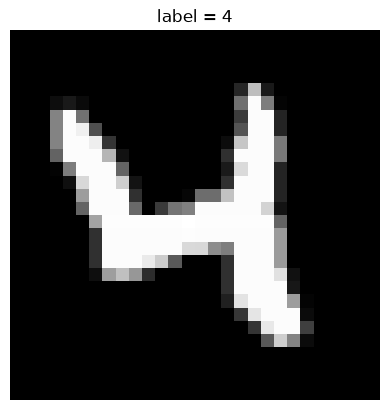

In [3]:
digit = x_train[20]

print("shape :", digit.shape)
print("dtype :", digit.dtype)
print("min   :", digit.min(), " max:", digit.max())
print("label :", y_train[0])

plt.imshow(digit, cmap="gray")
plt.title(f"label = {y_train[20]}")
plt.axis("off")
plt.show()

Background is 0 for parts with no ink

In [4]:
# The middle of the digit, printed as raw numbers.
np.set_printoptions(linewidth=200)
print(digit[10:18, 8:20])

[[100   0   0   0   0   0   0   0  26 218 252 252]
 [207  19   0   0   0   0   0   0  49 252 252 252]
 [252  48   0   0   0   6 109 109 194 252 252 252]
 [252 105   0  58 116 128 252 252 252 252 252 212]
 [253 253 253 253 253 255 253 253 253 253 253 253]
 [252 252 252 252 252 253 252 252 252 252 252 252]
 [252 252 252 252 252 217 216 141 126 252 252 252]
 [252 252 234 204  89   0   0   0  49 252 252 252]]


In [5]:
rows = np.where(digit.sum(axis=1) > 0)[0]  # Rows that contain ink which are always 4 pixes inward all four sides of the image.
cols = np.where(digit.sum(axis=0) > 0)[0]

print("rows containing ink:", rows.min(), "to", rows.max(), f"-> height {rows.max()-rows.min()+1}")
print("cols containing ink:", cols.min(), "to", cols.max(), f"-> width  {cols.max()-cols.min()+1}")
print("margin top/bottom/left/right:",
      rows.min(), 27 - rows.max(), cols.min(), 27 - cols.max())

rows containing ink: 4 to 23 -> height 20
cols containing ink: 3 to 22 -> width  20
margin top/bottom/left/right: 4 4 3 5


saving all the images in computer memory

In [6]:
bank = {d: np.where(y_train == d)[0] for d in range(10)}

for d in range(10):
    print(d, "->", len(bank[d]), "examples")

0 -> 5923 examples
1 -> 6742 examples
2 -> 5958 examples
3 -> 6131 examples
4 -> 5842 examples
5 -> 5421 examples
6 -> 5918 examples
7 -> 6265 examples
8 -> 5851 examples
9 -> 5949 examples


## 1.5 Compose a multi-digit number

This is what `compose_numbers.py` does: pick one image per digit and stack
them side by side with a random gap between them.

I am composing a **known** number (`4 2 7 1 0`) rather than a random one, so
that later I can check whether my segmentation recovered the right answer.

composed shape: (28, 161)
dtype: uint8  range: 0 - 255
ground truth: [4, 2, 7, 1, 0]


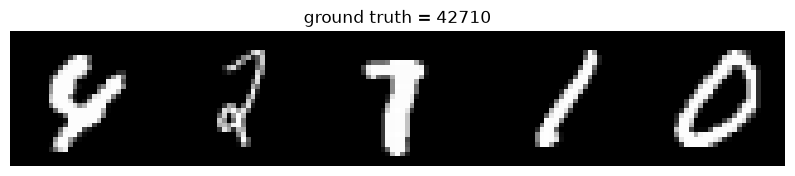

In [7]:
def compose(digits, gap_range=(0, 10), rng=random):
    """Stack one random MNIST image per digit, left to right.

    Returns the composed image and the list of digits used (ground truth).
    """
    parts = []
    for i, d in enumerate(digits):
        idx = rng.choice(list(bank[d]))
        parts.append(x_train[idx])
        if i < len(digits) - 1:
            gap = rng.randint(*gap_range)
            parts.append(np.zeros((28, gap), dtype=np.uint8))
    return np.hstack(parts), list(digits)


true_digits = [4, 2, 7, 1, 0]
number_img, truth = compose(true_digits)

print("composed shape:", number_img.shape)
print("dtype:", number_img.dtype, " range:", number_img.min(), "-", number_img.max())
print("ground truth:", truth)

plt.figure(figsize=(10, 2))
plt.imshow(number_img, cmap="gray")
plt.title(f"ground truth = {''.join(map(str, truth))}")
plt.axis("off")
plt.show()

In [8]:
Image.fromarray(number_img).save(os.path.join(DATA_DIR, "result.png"))
print("saved to", os.path.join(DATA_DIR, "result.png"))

saved to ../data\result.png


Vertical Projection

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = "../data"

# Reload the image from disk so this step stands on its own.
number_img = np.array(Image.open(os.path.join(DATA_DIR, "result.png")))

print("image shape:", number_img.shape, " (height, width)")
print("ground truth digits:", truth)   # 'truth' came from Step 1

image shape: (28, 161)  (height, width)
ground truth digits: [4, 2, 7, 1, 0]


Sum of each column, if zero, means theres a gap

In [10]:
profile = number_img.sum(axis=0)

print("profile shape:", profile.shape)
print("one value per column:", profile.shape[0], "==", number_img.shape[1])
print()
print("first 40 values:")
print(profile[:175])

profile shape: (161,)
one value per column: 161 == 161

first 40 values:
[   0    0    0    0    0    0    0    0  980 2315 3302 4018 4233 3389 2684 2277 1827 1553 1658 1441 1233 1068  998  391    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0  568 1113  900 1210 1571 1822 1038 1077 1329  878    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  126  656  845  716 1145
 3040 4545 5068 4919 4010 2411 1352  719   60    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  413 1124 1625 1865 1848 1354 1326 1309
 1229 1296 1536 1453  803   60    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  535 1559 2157 2292 1911 1934 1935 1842 1934 1856 1994 1819 1691 1687 2063 2647 2410  383
    0    0    0    0    0]


## 2.2 Look at it

The plot below is lined up directly underneath the image. Every valley that
touches zero is a gap between two digits.

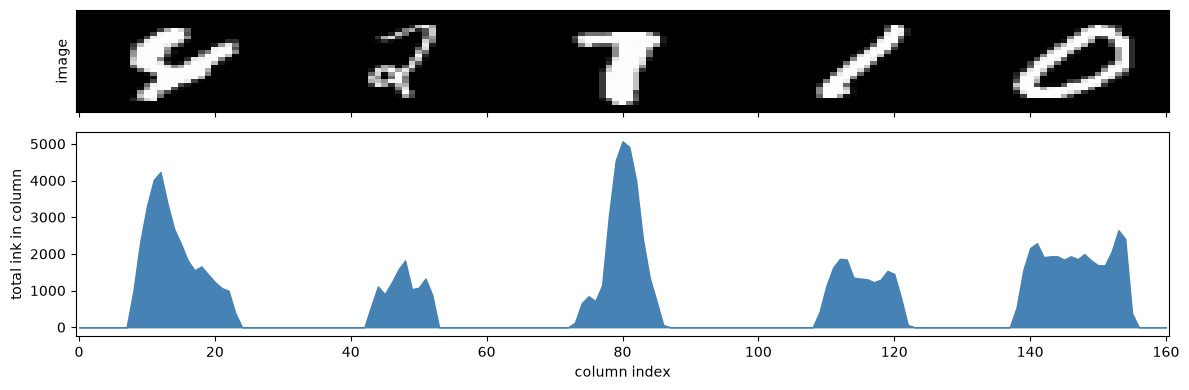

In [11]:
fig, (ax_img, ax_prof) = plt.subplots(
    2, 1, figsize=(12, 4), sharex=True,
    gridspec_kw={"height_ratios": [1, 2]}
)

ax_img.imshow(number_img, cmap="gray", aspect="auto")
ax_img.set_ylabel("image")
ax_img.set_yticks([])

ax_prof.fill_between(range(len(profile)), profile, color="steelblue")
ax_prof.set_ylabel("total ink in column")
ax_prof.set_xlabel("column index")
ax_prof.margins(x=0)

plt.tight_layout()
plt.show()

## 2.3 Turn the valleys into digit boundaries

Now the actual algorithm. I walk along the profile left to right:

- ink appears where there was none  ->  a digit **starts**
- ink disappears  ->  the digit **ends**

Each start/end pair is one digit. Two extra details matter:

- a digit touching the very edge of the image never "ends" in the loop, so I
  close the last span after the loop finishes,
- `min_width` throws away specks that are too narrow to be a real digit.

In [12]:
def find_digit_spans(profile, threshold=0, min_width=1):
    """Find (start, end) column ranges containing ink.

    threshold : a column counts as 'ink' if its total is ABOVE this
    min_width : ignore spans narrower than this many columns
    """
    spans = []
    start = None

    for i, value in enumerate(profile):
        if value > threshold and start is None:
            start = i                       # digit begins here
        elif value <= threshold and start is not None:
            if i - start >= min_width:
                spans.append((start, i))    # digit ends here
            start = None

    # digit that runs to the right-hand edge
    if start is not None and len(profile) - start >= min_width:
        spans.append((start, len(profile)))

    return spans


spans = find_digit_spans(profile)

print("spans found:", spans)
print()
print("digits found :", len(spans))
print("digits expected:", len(truth))
print("MATCH" if len(spans) == len(truth) else "MISMATCH")

spans found: [(8, 24), (43, 53), (73, 87), (109, 123), (138, 156)]

digits found : 5
digits expected: 5
MATCH


## 2.4 Draw the cuts

Red lines where the algorithm thinks each digit starts and ends. This is the
check that matters — numbers can look right while the cuts are wrong.

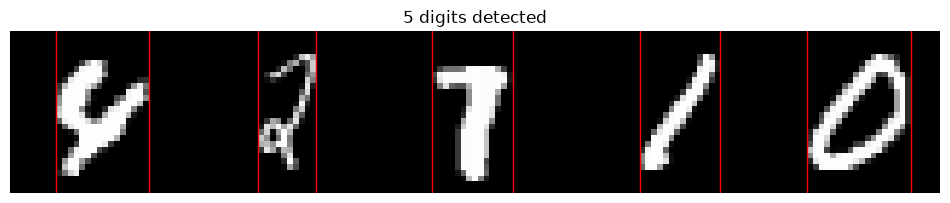

In [13]:
plt.figure(figsize=(12, 2.5))
plt.imshow(number_img, cmap="gray")

for (start, end) in spans:
    plt.axvline(start - 0.5, color="red", linewidth=1)
    plt.axvline(end - 0.5, color="red", linewidth=1)

plt.title(f"{len(spans)} digits detected")
plt.axis("off")
plt.show()

## 2.5 Cut the digits out

This is the payoff. One wide image goes in, a list of small images comes out.
Each one is a single digit, ready for the classifier.

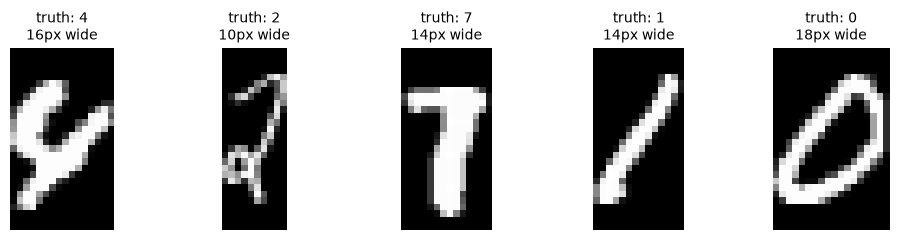

crop 0: shape (28, 16)
crop 1: shape (28, 10)
crop 2: shape (28, 14)
crop 3: shape (28, 14)
crop 4: shape (28, 18)


In [14]:
crops = [number_img[:, start:end] for (start, end) in spans]

fig, axes = plt.subplots(1, len(crops), figsize=(2 * len(crops), 2.5))
if len(crops) == 1:
    axes = [axes]

for ax, crop, true_digit in zip(axes, crops, truth):
    ax.imshow(crop, cmap="gray")
    ax.set_title(f"truth: {true_digit}\n{crop.shape[1]}px wide", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

for i, crop in enumerate(crops):
    print(f"crop {i}: shape {crop.shape}")

## 2.6 The question I have to be honest about

The method almost certainly got 5/5. Before I claim it works, I should ask
*why* it worked so easily.

Run the cell below. It composes numbers with **no gap at all** between the
digits, which sounds like it should break the method completely.

In [15]:
for trial_gap in [10, 5, 0]:
    img, t = compose([3, 1, 4, 1, 5], gap_range=(trial_gap, trial_gap))
    found = find_digit_spans(img.sum(axis=0))
    print(f"gap = {trial_gap:2d}px -> found {len(found)} digits (expected {len(t)})",
          "OK" if len(found) == len(t) else "FAILED")

gap = 10px -> found 5 digits (expected 5) OK
gap =  5px -> found 5 digits (expected 5) OK
gap =  0px -> found 5 digits (expected 5) OK


### Why it still works at gap = 0

Because of what I measured back in Step 1: **MNIST digits carry their own
built-in margin**. The ink only occupies roughly columns 4-24 of the 28-wide
box, so even when two boxes are pushed hard against each other there are still
about 7 blank columns between the ink.

So `compose_numbers.py` can never produce genuinely touching digits. My
projection method is not being tested properly by it.

**This is the single most useful thing I can put in the report.** The method
isn't good because it's clever; it's succeeding because the input is easy.

To break it on purpose I would need to *overlap* the digit boxes, or use real
handwriting where someone's 4 runs into their 2. That is Step 7.

---
## Record for the report — Method A

| | |
|---|---|
| Method | Vertical projection profile |
| How it works | Sum ink per column; runs of non-zero columns are digits |
| Digits found / expected (gap 0-10) | |
| Digits found / expected (gap 0) | |
| Speed | Very fast, one pass over the columns |
| Assumption it depends on | |
| Where it will fail | |

**Next:** Step 3 does the same job with connected components, which does not
assume the digits are separated left-to-right at all.
